# Análise Estatística e Diagnóstico de Vendas — E-commerce**Objetivo:** identificar padrões de comportamento de compra, sazonalidade, desempenho por categoria/estado/forma de pagamento e investigar se cancelamentos e devoluções estão associados a algum desses fatores, com apoio de testes estatísticos (Qui-quadrado e Mann-Whitney).**Fonte dos dados:** `Ecommerce_limpo.csv` — 480 pedidos, contendo dados de cliente, produto, valor, forma de pagamento, localização e status do pedido.**Estrutura do notebook:**1. Importação das bibliotecas2. Importação dos dados3. Entendendo os dados4. Análise Exploratória de Dados (EDA)5. Diagnóstico Geral de Receita6. Sazonalidade e Tendência7. Cancelamentos e Devoluções8. Conclusões

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

## 2. Importação dos dados

Os dados são carregados a partir de Ecommerce_limpo.csv, convertendo a coluna data_pedido para o tipo *datetime*. Uma cópia (df) é usada para preservar o dataframe original (df_limpo).

In [2]:
df_limpo=pd.read_csv('Ecommerce_limpo.csv',parse_dates=['data_pedido'])
df= df_limpo.copy()

## 3. Entendendo os dados

Primeiras e últimas linhas do dataset, para checar consistência de formato e valores:

In [3]:
df.head()

,id_pedido,data_pedido,id_cliente,nome_cliente,email,telefone,idade,cidade,estado,categoria_produto,produto,quantidade,preco_unitario,valor_total,forma_pagamento,status_pedido,avaliacao_cliente,regiao
0,1041,2023-07-26,306,Renan Ribeiro,leonardo88@example.org,NaN,59.0,Florianópolis,SC,roupa,Camiseta Básica,2,49.9,99.8,Cartão De Débito,Devolvido,5,Sul
1,1047,2024-03-27,195,Diego Melo,novaisdavi@example.com,5.511973e+12,70.0,Contagem,MG,roupa,Calça Jeans,4,129.9,519.6,Cartão De Débito,Processando,10,Sudeste
2,1344,2023-10-16,165,Nicole Moreira,liviacaldeira@example.com,NaN,49.0,Porto Alegre,RS,esporte e lazer,Bola De Futebol Oficial,4,89.9,359.6,Boleto Bancário,Cancelado,1,Sul
3,1137,2025-08-01,45,Fernanda Freitas,ucorreia@example.com,NaN,41.0,Olinda,PE,roupa,Vestido Casual,3,159.9,479.7,Boleto Bancário,Em Transporte,1,Nordeste
4,1110,2023-08-27,149,Cecilia Novaes,ryanborges@example.org,5.585942e+12,29.0,Petrópolis,RJ,roupa,Calça Jeans,2,129.9,259.8,Cartão De Crédito,Cancelado,1,Sudeste


In [4]:
df.tail()

,id_pedido,data_pedido,id_cliente,nome_cliente,email,telefone,idade,cidade,estado,categoria_produto,produto,quantidade,preco_unitario,valor_total,forma_pagamento,status_pedido,avaliacao_cliente,regiao
475,1168,2025-11-01,139,Aurora Oliveira,NaN,NaN,67.0,Contagem,MG,roupa,Calça Jeans,1,129.9,129.9,Pix,Devolvido,4,Sudeste
476,1007,2024-12-25,109,Esther Freitas,novaesdavi-lucas@example.net,5.585931e+12,67.0,Santos,SP,roupa,Jaqueta CortaVento,3,199.9,599.7,Cartão De Débito,Devolvido,4,Sudeste
477,1221,2024-03-17,265,Luiz Felipe Melo,nascimentopedro@example.net,5.511973e+12,59.0,Nan,RS,eletrônico,Notebook,2,3299.0,6598.0,Boleto Bancário,Devolvido,5,Sul
478,1462,2025-08-22,139,Davi Miguel Freitas,guerrarenan@example.org,5.579990e+12,36.0,Duque De Caxias,RJ,roupa,Vestido Casual,2,159.9,319.8,Pix,Cancelado,5,Sudeste
479,1083,2023-10-17,224,Allana Rodrigues,enzo-gabrielalves@example.org,5.579961e+12,NaN,Sobral,CE,casa e decoração,Luminária De Mesa,1,89.9,89.9,Boleto Bancário,Processando,2,Nordeste


Estrutura geral, tipos de dados e valores ausentes:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_pedido          480 non-null    int64         
 1   data_pedido        480 non-null    datetime64[ns]
 2   id_cliente         480 non-null    int64         
 3   nome_cliente       457 non-null    object        
 4   email              430 non-null    object        
 5   telefone           331 non-null    float64       
 6   idade              439 non-null    float64       
 7   cidade             473 non-null    object        
 8   estado             468 non-null    object        
 9   categoria_produto  480 non-null    object        
 10  produto            480 non-null    object        
 11  quantidade         480 non-null    int64         
 12  preco_unitario     480 non-null    float64       
 13  valor_total        471 non-null    float64       
 14  forma_paga

### 3.1 Remoção de dados sensíveis

As colunas id_cliente, nome_cliente, email e telefone são removidas antes da análise, pois são dados pessoais identificáveis (PII) e não são necessárias para os objetivos estatísticos e de negócio deste projeto.

In [6]:
df=df.drop(columns=['id_cliente','nome_cliente','email','telefone'])

Dataframe já tratado, sem colunas de identificação pessoal:

In [7]:
df

,id_pedido,data_pedido,idade,cidade,estado,categoria_produto,produto,quantidade,preco_unitario,valor_total,forma_pagamento,status_pedido,avaliacao_cliente,regiao
0,1041,2023-07-26,59.0,Florianópolis,SC,roupa,Camiseta Básica,2,49.9,99.8,Cartão De Débito,Devolvido,5,Sul
1,1047,2024-03-27,70.0,Contagem,MG,roupa,Calça Jeans,4,129.9,519.6,Cartão De Débito,Processando,10,Sudeste
2,1344,2023-10-16,49.0,Porto Alegre,RS,esporte e lazer,Bola De Futebol Oficial,4,89.9,359.6,Boleto Bancário,Cancelado,1,Sul
3,1137,2025-08-01,41.0,Olinda,PE,roupa,Vestido Casual,3,159.9,479.7,Boleto Bancário,Em Transporte,1,Nordeste
4,1110,2023-08-27,29.0,Petrópolis,RJ,roupa,Calça Jeans,2,129.9,259.8,Cartão De Crédito,Cancelado,1,Sudeste
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,1168,2025-11-01,67.0,Contagem,MG,roupa,Calça Jeans,1,129.9,129.9,Pix,Devolvido,4,Sudeste
476,1007,2024-12-25,67.0,Santos,SP,roupa,Jaqueta CortaVento,3,199.9,599.7,Cartão De Débito,Devolvido,4,Sudeste
477,1221,2024-03-17,59.0,Nan,RS,eletrônico,Notebook,2,3299.0,6598.0,Boleto Bancário,Devolvido,5,Sul
478,1462,2025-08-22,36.0,Duque De Caxias,RJ,roupa,Vestido Casual,2,159.9,319.8,Pix,Cancelado,5,Sudeste


## 4. Análise Exploratória de Dados (EDA)

Estatísticas descritivas das variáveis numéricas:

In [8]:
df.describe()

,id_pedido,data_pedido,idade,quantidade,preco_unitario,valor_total,avaliacao_cliente
count,480.000000,480,439.000000,480.000000,480.000000,471.000000,480.000000
mean,1240.500000,2024-08-01 05:15:00.000000256,44.801822,2.254167,493.200312,1198.313822,3.787500
min,1001.000000,2023-01-05 00:00:00,18.000000,0.000000,29.900000,28.410000,0.000000
25%,1120.750000,2023-11-27 06:00:00,30.500000,1.000000,79.900000,99.900000,3.000000
50%,1240.500000,2024-07-22 00:00:00,44.000000,2.000000,149.900000,299.700000,4.000000
75%,1360.250000,2025-05-02 06:00:00,58.000000,3.000000,289.900000,999.000000,4.000000
max,1480.000000,2025-12-27 00:00:00,75.000000,5.000000,3299.000000,16495.000000,10.000000
std,138.708327,NaN,16.474954,1.310780,770.237813,2302.325310,1.421814


**Leitura rápida do `describe()`:** a idade dos clientes varia de 18 a 75 anos (média ≈ 45 anos); a quantidade de itens por pedido vai de 0 a 5 (pedidos com quantidade 0 podem indicar cancelamento antes da confirmação do item, vale investigar); e há valores ausentes em `idade`, `valor_total` e `avaliacao_cliente`, o que já era esperado pelo `.info()` visto na seção anterior.

Seleção das variáveis numéricas para análise univariada:

In [9]:
colum=['idade','quantidade','preco_unitario','valor_total','avaliacao_cliente']

### 4.1 Distribuição das variáveis

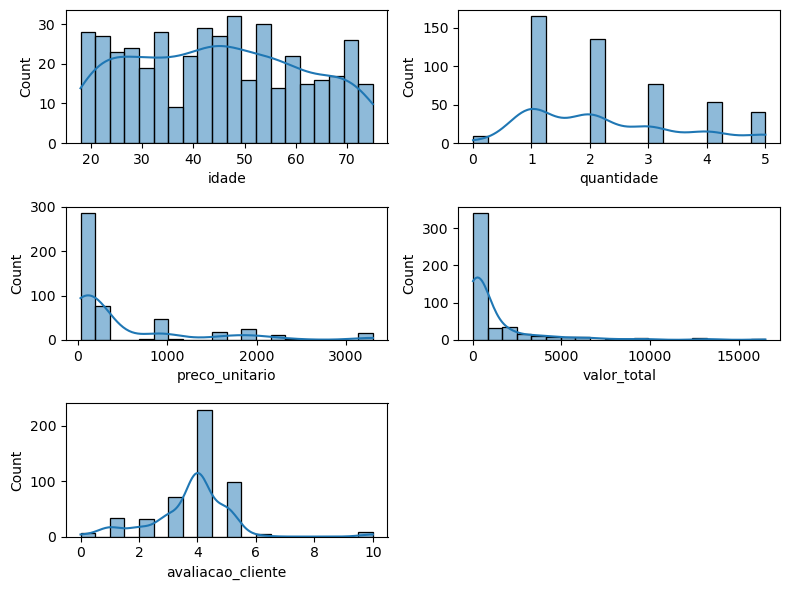

In [10]:
fig, axes= plt.subplots(3,2,figsize=(8,6))
axes=axes.flatten()
for i,col in enumerate(colum):
    sns.histplot(df[col],ax=axes[i],kde=True,bins=20)
fig.delaxes(axes[-1])
plt.tight_layout()


As variáveis `quantidade`, `preco_unitario` e `valor_total` apresentam assimetria à direita (cauda longa de pedidos de maior valor), enquanto `idade` e `avaliacao_cliente` têm distribuição mais próxima do uniforme/normal dentro de seus intervalos.

### 4.2 Outliers

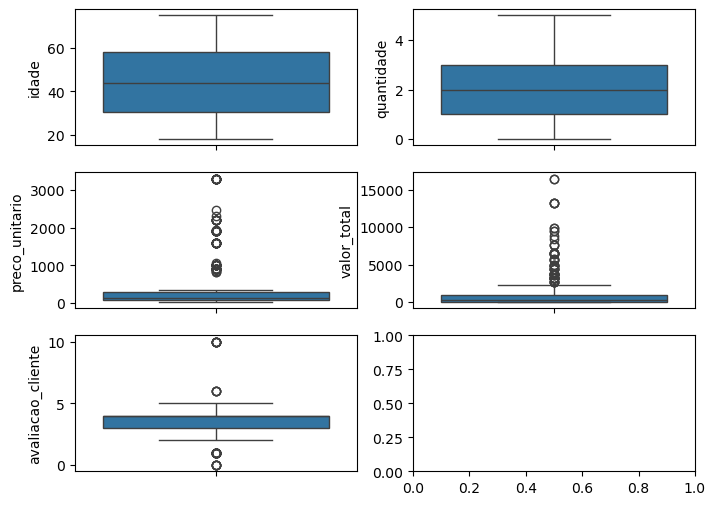

In [11]:
fig, axes= plt.subplots(3,2,figsize=(8,6))
axes=axes.flatten()
for i,col in enumerate(colum):
    sns.boxplot(df[col],ax=axes[i])

Os boxplots ajudam a confirmar a assimetria observada nos histogramas: `valor_total` e `preco_unitario` concentram outliers acima do terceiro quartil, coerente com uma cauda de pedidos de maior valor. Esses outliers não foram removidos nesta análise por representarem vendas legítimas de maior valor, e não erros de coleta.

### 4.3 Correlação entre variáveis (Spearman)

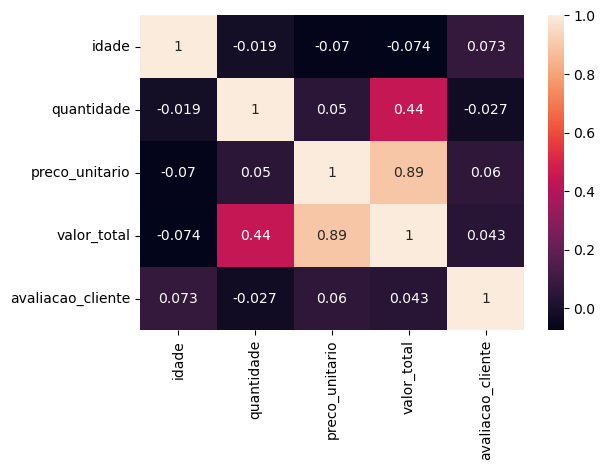

In [12]:
matriz=df[colum].corr('spearman')

sns.heatmap(matriz,annot=True)
plt.tight_layout()

A correlação de Spearman foi escolhida por não assumir relação linear nem distribuição normal entre as variáveis. O objetivo aqui é apenas identificar se alguma variável numérica se move junto de outra (ex.: `quantidade` x `valor_total`) antes de avançar para as análises de receita e cancelamento.

## 5. Diagnóstico Geral de Receita

Faturamento total do período:

In [ ]:
faturamento = df['valor_total'].sum()
print(f'Faturamento total do período: R$ {faturamento:,.2f}')

Ticket médio por pedido:

In [ ]:
ticket_medio = faturamento / df['valor_total'].count()
print(f'Ticket médio por pedido: R$ {ticket_medio:,.2f}')

Receita por categoria de produto:

In [13]:
df.groupby('categoria_produto')['valor_total'].sum()

categoria_produto
beleza               15426.91
casa e decoração    114580.38
eletrônico          323839.08
esporte e lazer      70714.93
livro                10713.81
roupa                29130.70
Name: valor_total, dtype: float64

**Eletrônico** é a categoria líder em faturamento (R$ 323.839,08), respondendo por mais da metade da receita total, seguida por **casa e decoração** (R$ 114.580,38). **Livro** (R$ 10.713,81) e **beleza** (R$ 15.426,91) são as categorias de menor participação — apesar de o volume de itens vendidos ser parecido entre categorias (ver próxima célula), o que indica que o ticket unitário do eletrônico é bem mais alto.

Quantidade de itens vendidos por categoria:

In [14]:
df.groupby('categoria_produto')['quantidade'].sum()

categoria_produto
beleza              159
casa e decoração    194
eletrônico          172
esporte e lazer     180
livro               194
roupa               183
Name: quantidade, dtype: int64

O volume de itens vendidos é bastante equilibrado entre categorias (159 a 194 unidades), reforçando que a diferença de faturamento vista acima vem do **valor unitário** dos produtos, e não do volume vendido.

Ticket médio por forma de pagamento:

In [15]:
df.groupby('forma_pagamento')['valor_total'].mean()

forma_pagamento
Boleto Bancário      1164.587236
Cartão De Crédito    1158.923894
Cartão De Débito     1447.399524
Não Informado         357.741000
Pix                  1129.236303
Name: valor_total, dtype: float64

O **Cartão de Débito** tem o maior ticket médio (R$ 1.447,40), à frente de Boleto (R$ 1.164,59), Cartão de Crédito (R$ 1.158,92) e Pix (R$ 1.129,24). Pedidos sem forma de pagamento informada têm ticket muito menor (R$ 357,74) — provavelmente concentrados em pedidos cancelados antes da confirmação do pagamento.

## 6. Sazonalidade e Tendência

Valor médio dos pedidos ao longo dos meses do ano:

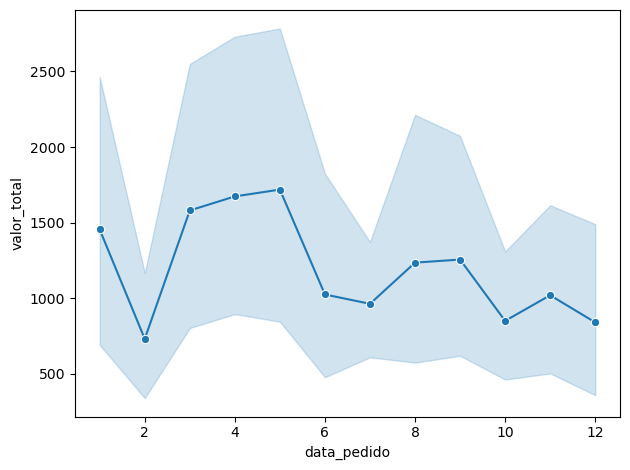

In [16]:
sns.lineplot(df,x=df['data_pedido'].dt.month,y='valor_total', marker='o')
plt.tight_layout()

O gráfico permite visualizar se há meses de pico ou queda no valor médio dos pedidos (ex.: efeito de datas comerciais como Black Friday ou Natal). Vale cruzar esse padrão com o calendário de campanhas de marketing da empresa, se houver, para confirmar causa e efeito.

## 7. Cancelamentos e Devoluções

Esta seção investiga o percentual de pedidos cancelados ou devolvidos — um indicador direto de saúde operacional e de satisfação do cliente.

In [ ]:
cancelado = (df[['status_pedido']] == 'Cancelado').sum()
devolvido = (df[['status_pedido']] == 'Devolvido').sum()
total = cancelado + devolvido

porcentagem = (total / df['status_pedido'].count()) * 100
print(f'Percentual de pedidos cancelados ou devolvidos: {porcentagem.iloc[0]:.2f}%')

Cancelamento e devolução por categoria de produto (% dentro de cada categoria):

In [17]:
categoria = (pd.crosstab(df['categoria_produto'],df['status_pedido'],normalize='index') * 100).round(2)

categoria

status_pedido,Cancelado,Devolvido,Em Transporte,Entregue,Processando
categoria_produto,,,,,
beleza,16.18,32.35,19.12,14.71,17.65
casa e decoração,16.67,22.22,20.00,15.56,25.56
eletrônico,21.79,16.67,16.67,28.21,16.67
esporte e lazer,27.38,14.29,20.24,23.81,14.29
livro,19.05,17.86,15.48,21.43,26.19
roupa,21.05,15.79,21.05,22.37,19.74


**Esporte e lazer** tem a maior taxa de cancelamento (27,38%) e **beleza** a maior taxa de devolução (32,35%). **Eletrônico** se destaca por ter a maior taxa de entrega concluída (28,21%) e cancelamento relativamente alto (21,79%), mas devolução baixa (16,67%) — ou seja, quando o pedido de eletrônico é cancelado, tende a ser antes do envio, não depois.

Cancelamento e devolução por estado (% dentro de cada estado):

In [18]:
estado = (pd.crosstab(df['estado'],df['status_pedido'],normalize='index') * 100).round(2)

estado

status_pedido,Cancelado,Devolvido,Em Transporte,Entregue,Processando
estado,,,,,
AM,18.37,18.37,22.45,14.29,26.53
BA,13.95,20.93,25.58,16.28,23.26
CE,22.22,20.00,13.33,20.00,24.44
DF,16.00,28.00,28.00,8.00,20.00
MG,15.79,28.95,13.16,21.05,21.05
PE,18.60,9.30,27.91,23.26,20.93
PR,27.27,15.15,12.12,33.33,12.12
RJ,29.03,12.90,16.13,22.58,19.35
RS,24.39,19.51,19.51,21.95,14.63


Não há um padrão geográfico muito forte: as taxas de cancelamento variam de forma relativamente próxima entre os estados (a maioria entre 14% e 27%), sem um estado que se destaque como outlier extremo. Isso já sugere, antes mesmo do teste estatístico, que a localização pode não ser um fator determinante — o que será confirmado (ou não) pelo teste do Qui-quadrado adiante.

Cancelamento e devolução por forma de pagamento (% dentro de cada forma de pagamento):

In [19]:
pagamento = (pd.crosstab(df['forma_pagamento'],df['status_pedido'],normalize='index') * 100).round(2)

pagamento

status_pedido,Cancelado,Devolvido,Em Transporte,Entregue,Processando
forma_pagamento,,,,,
Boleto Bancário,16.13,25.00,13.71,21.77,23.39
Cartão De Crédito,22.41,7.76,26.72,22.41,20.69
Cartão De Débito,21.50,24.30,16.82,23.36,14.02
Não Informado,20.00,10.00,30.00,30.00,10.00
Pix,22.13,22.13,17.21,16.39,22.13


**Cartão de Crédito** tem a maior taxa de cancelamento (22,41%) e a menor taxa de devolução (7,76%). **Pix** e **Cartão de Débito** têm as maiores taxas de devolução (22,13% e 24,30%). A categoria 'Não Informado' tem taxas mais altas de cancelamento e entrega e mais baixas de devolução, mas seu volume de pedidos é pequeno, então esse resultado deve ser lido com cautela.

Visualização consolidada — cancelamento e devolução por categoria:

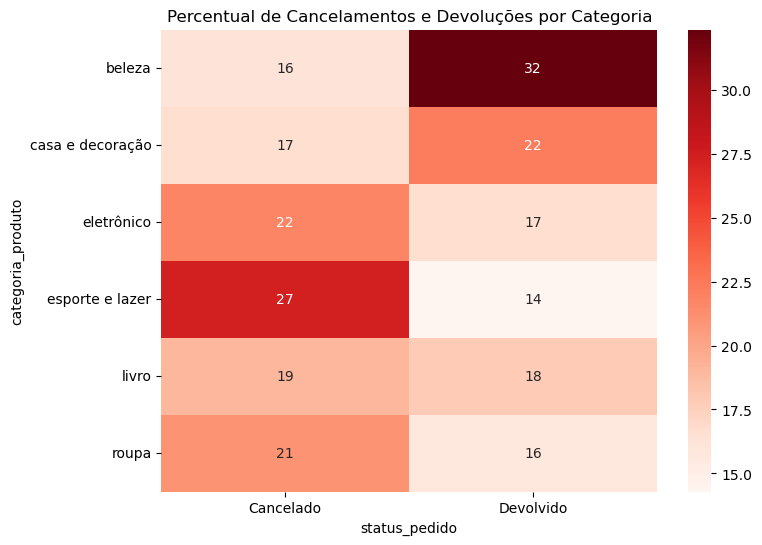

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    categoria[['Cancelado','Devolvido']],
    annot=True,
    cmap='Reds'
)

plt.title('Percentual de Cancelamentos e Devoluções por Categoria')
plt.show()

### 7.1 Testes de associação estatísticaAs seções anteriores mostraram diferenças percentuais entre grupos, mas para saber se essas diferenças são estatisticamente significativas (e não apenas ruído amostral), aplicamos o teste **Qui-quadrado de independência** entre `status_pedido` e cada variável categórica, e o teste **Mann-Whitney U** para comparar o valor dos pedidos cancelados vs. entregues. Nível de significância adotado: α = 0,05.

In [21]:
tabela = pd.crosstab(df['forma_pagamento'],df['status_pedido'])
st.chi2_contingency(tabela)

Chi2ContingencyResult(statistic=np.float64(25.88163931712309), pvalue=np.float64(0.05571657395374351), dof=16, expected_freq=array([[25.36951983, 24.33402923, 23.29853862, 26.14613779, 24.85177453],
       [23.73277662, 22.76409186, 21.7954071 , 24.45929019, 23.24843424],
       [21.8914405 , 20.99791232, 20.10438413, 22.56158664, 21.44467641],
       [ 2.04592902,  1.96242171,  1.87891441,  2.1085595 ,  2.00417537],
       [24.96033403, 23.94154489, 22.92275574, 25.72442589, 24.45093946]]))

**p-valor = 0,0557.** Está acima de 0,05, então, a rigor, não rejeitamos a hipótese de independência — mas o valor é bem próximo do limite, sugerindo uma associação marginal entre forma de pagamento e status do pedido que pode merecer atenção com uma amostra maior.

In [22]:
tabela = pd.crosstab(df['categoria_produto'],df['status_pedido'])
st.chi2_contingency(tabela)


Chi2ContingencyResult(statistic=np.float64(22.439286799370823), pvalue=np.float64(0.31715711507105926), dof=20, expected_freq=array([[13.88333333, 13.31666667, 12.75      , 14.30833333, 13.74166667],
       [18.375     , 17.625     , 16.875     , 18.9375    , 18.1875    ],
       [15.925     , 15.275     , 14.625     , 16.4125    , 15.7625    ],
       [17.15      , 16.45      , 15.75      , 17.675     , 16.975     ],
       [17.15      , 16.45      , 15.75      , 17.675     , 16.975     ],
       [15.51666667, 14.88333333, 14.25      , 15.99166667, 15.35833333]]))

**p-valor = 0,3172.** Bem acima de 0,05: não há evidência estatística de associação entre categoria de produto e status do pedido. As diferenças percentuais vistas na seção 7 provavelmente refletem variação amostral, não um efeito real da categoria sobre cancelamento/devolução.

In [23]:
cancelados = df.loc[df['status_pedido']=='Cancelado','valor_total']

entregues = df.loc[df['status_pedido']=='Entregue','valor_total']

u, p = st.mannwhitneyu(cancelados.dropna(),
                    entregues.dropna())
p

np.float64(0.30092791878724257)

**p-valor = 0,3009.** Acima de 0,05: não há diferença estatisticamente significativa entre o valor dos pedidos cancelados e o dos pedidos entregues. Ou seja, pedidos de maior valor não têm mais (nem menos) chance de serem cancelados.

## 8. Conclusões- **Receita:** o faturamento total do período foi de aproximadamente R$ 564.405,81, com ticket médio de ~R$ 1.198,31 por pedido. A categoria **eletrônico** concentra a maior parte da receita, não por vender mais unidades, mas por ter o maior valor unitário.- **Forma de pagamento:** Cartão de Débito tem o maior ticket médio; pedidos sem forma de pagamento informada têm ticket muito baixo, provavelmente por serem cancelados antes da confirmação do pagamento.- **Cancelamentos e devoluções:** as diferenças percentuais entre categorias, estados e formas de pagamento existem, mas os testes estatísticos indicam que **apenas a forma de pagamento** mostra uma associação marginal (p = 0,0557) com o status do pedido — categoria de produto (p = 0,317) e valor do pedido (p = 0,301) não mostraram relação estatisticamente significativa com cancelamento.- **Recomendação:** as próximas investigações podem focar em forma de pagamento (por ex., problemas específicos com um meio de pagamento) e ampliar a amostra para confirmar se a associação marginal encontrada se mantém.